# Unit Roots Deep Dive — Exam Prep
**ECON 522 — Forecasting and Macroeconomic Analytics**  
Professor Elena Pesavento, Emory University

This notebook covers everything from Week 7 on unit roots: definitions, properties, why they matter, how to test, and how to make decisions. Each section includes **visual demonstrations**, **worked examples**, and **practice problems** to prepare for the exam.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## Part 1: What Is a Unit Root?

### The AR(1) Model and the Critical Boundary

Recall the AR(1) model:
$$y_t = \rho \, y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim WN(0, \sigma^2)$$

- If $|\rho| < 1$: **stationary** — shocks die out, variance is finite, mean-reverting
- If $\rho = 1$: **unit root (random walk)** — shocks are permanent, variance grows with time
- If $\rho > 1$: **explosive** — shocks amplify, unrealistic for most economic data

The name "unit root" comes from the characteristic polynomial of the AR(1): $\alpha(z) = 1 - \rho z$. The root is $z = 1/\rho$. When $\rho = 1$, the root equals one — a **unit** root.

### Key Definitions

| Model | Equation | Name |
|---|---|---|
| Random Walk | $y_t = y_{t-1} + \varepsilon_t$ | Unit root, no drift |
| Random Walk with Drift | $y_t = c + y_{t-1} + \varepsilon_t$ | Unit root with drift |
| Trend Stationary | $y_t = \alpha + ct + \Psi(L)\varepsilon_t$ | Deterministic trend |

### Integration Order
$y_t$ is **integrated of order $d$**, written $I(d)$, if the $d$-th difference is stationary.  
A random walk is $I(1)$ — one differencing yields $\Delta y_t = \varepsilon_t$ (white noise).

### Let's SEE the difference between rho values

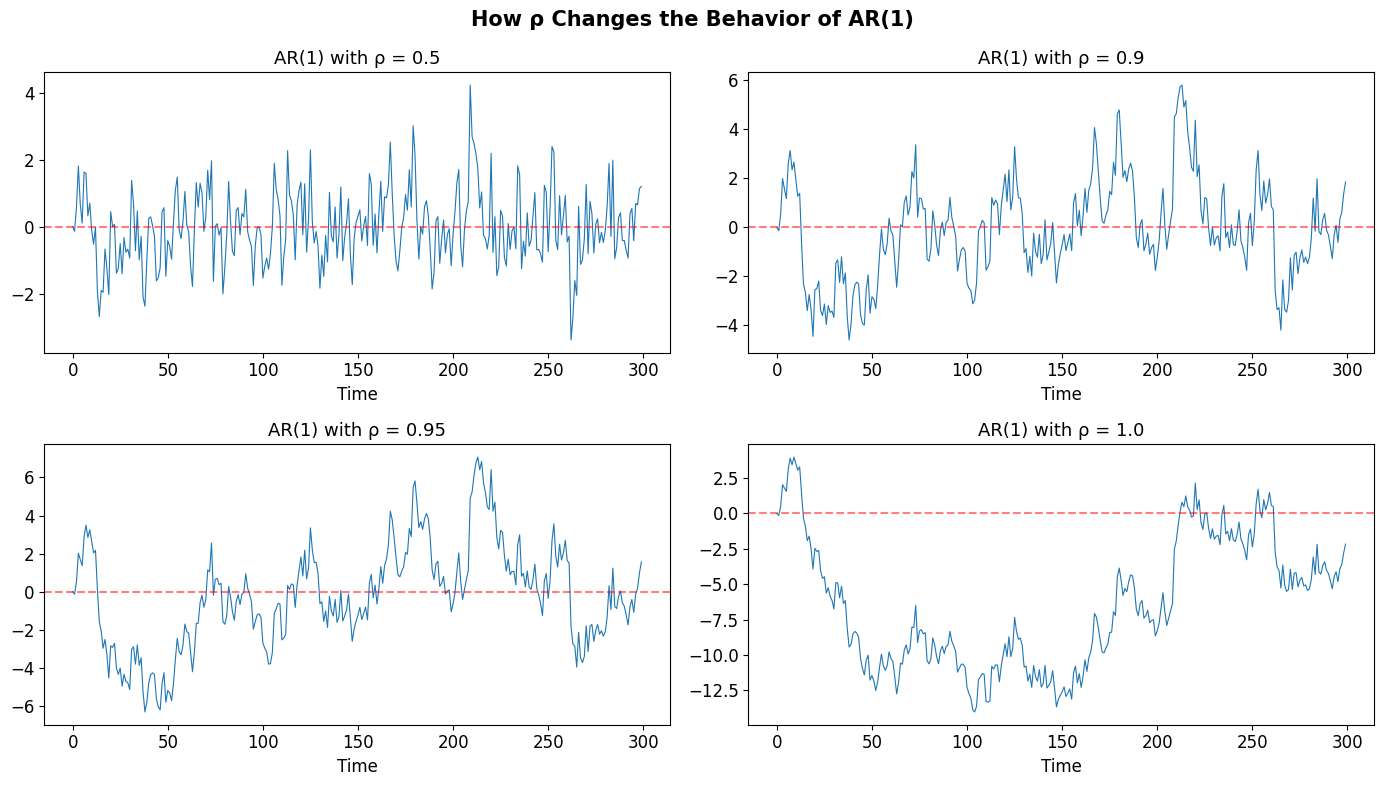

Notice:
  ρ=0.5: Quick mean-reversion, looks like noise around zero
  ρ=0.9: Slower mean-reversion, longer swings
  ρ=0.95: Very persistent — hard to tell from ρ=1 visually!
  ρ=1.0: Random walk — long swings, no mean-reversion, variance grows


In [2]:
# Simulate AR(1) processes with different rho values
T = 300
eps = np.random.normal(0, 1, T)
rho_values = [0.5, 0.9, 0.95, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, rho in enumerate(rho_values):
    y = np.zeros(T)
    for t in range(1, T):
        y[t] = rho * y[t-1] + eps[t]
    axes[i].plot(y, linewidth=0.8)
    axes[i].set_title(f'AR(1) with ρ = {rho}', fontsize=13)
    axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('Time')
    
plt.suptitle('How ρ Changes the Behavior of AR(1)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice:')
print('  ρ=0.5: Quick mean-reversion, looks like noise around zero')
print('  ρ=0.9: Slower mean-reversion, longer swings')
print('  ρ=0.95: Very persistent — hard to tell from ρ=1 visually!')
print('  ρ=1.0: Random walk — long swings, no mean-reversion, variance grows')

---
## Part 2: Properties of the Random Walk

### By back-substitution:
$$y_t = y_0 + \sum_{j=1}^{t} \varepsilon_j$$

The process is just the **cumulative sum** of all past shocks. No shock ever disappears.

### Key properties:

| Property | Random Walk | Stationary AR(1) |
|---|---|---|
| **Mean** | $E(y_t) = 0$ | $E(y_t) = 0$ |
| **Variance** | $\text{Var}(y_t) = t\sigma^2$ (grows!) | $\text{Var}(y_t) = \frac{\sigma^2}{1-\rho^2}$ (fixed) |
| **Autocorrelation** | $\rho_k \to 1$ as $t \to \infty$ | $\rho_k = \rho^k \to 0$ |
| **Shock effect** | Permanent | Decays as $\rho^s$ |
| **Stationarity** | NO (variance depends on $t$) | YES |

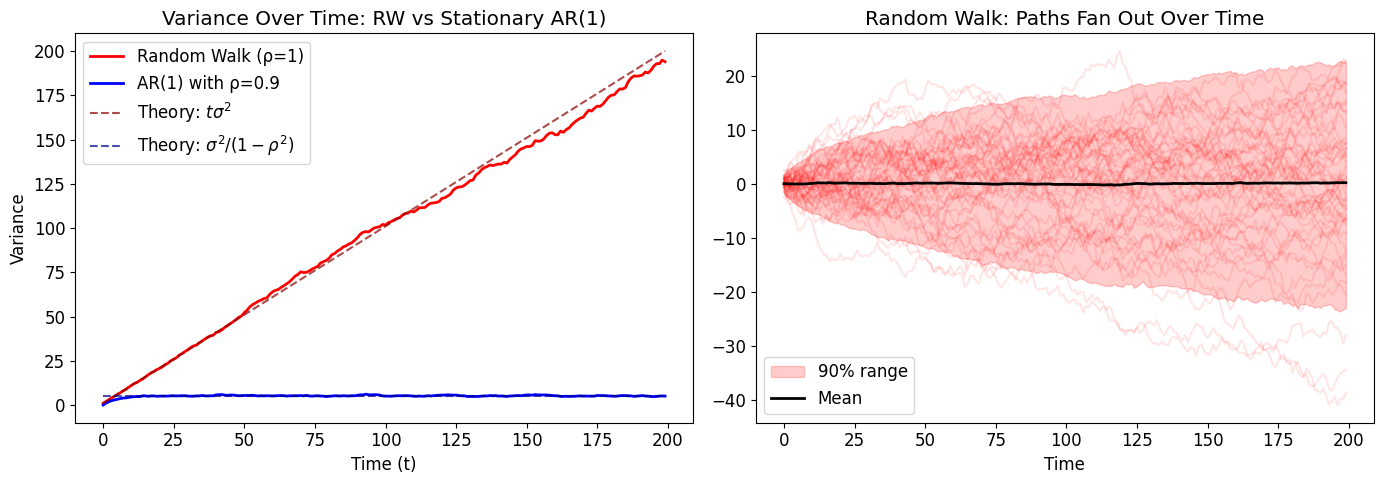

KEY EXAM POINT: The variance of a random walk grows linearly with t.
This is WHY it is not stationary — stationarity requires constant variance.


In [3]:
# DEMONSTRATE: Variance grows with time for a random walk
n_sims = 1000
T = 200

# Simulate many random walks
rw_paths = np.cumsum(np.random.normal(0, 1, (n_sims, T)), axis=1)
# Simulate many AR(1) with rho=0.9
ar_paths = np.zeros((n_sims, T))
for sim in range(n_sims):
    eps = np.random.normal(0, 1, T)
    for t in range(1, T):
        ar_paths[sim, t] = 0.9 * ar_paths[sim, t-1] + eps[t]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot variance over time
rw_var = np.var(rw_paths, axis=0)
ar_var = np.var(ar_paths, axis=0)

axes[0].plot(rw_var, label='Random Walk (ρ=1)', color='red', linewidth=2)
axes[0].plot(ar_var, label='AR(1) with ρ=0.9', color='blue', linewidth=2)
theoretical_rw = np.arange(1, T+1) * 1.0  # t * sigma^2
theoretical_ar = np.ones(T) * 1.0 / (1 - 0.9**2)  # sigma^2/(1-rho^2)
axes[0].plot(theoretical_rw, '--', color='darkred', alpha=0.7, label=r'Theory: $t\sigma^2$')
axes[0].plot(theoretical_ar, '--', color='darkblue', alpha=0.7, label=r'Theory: $\sigma^2/(1-\rho^2)$')
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Variance Over Time: RW vs Stationary AR(1)')
axes[0].legend()

# Show fan chart of random walk paths
for sim in range(50):
    axes[1].plot(rw_paths[sim], alpha=0.1, color='red')
axes[1].fill_between(range(T), 
                      np.percentile(rw_paths, 5, axis=0),
                      np.percentile(rw_paths, 95, axis=0),
                      alpha=0.2, color='red', label='90% range')
axes[1].plot(np.mean(rw_paths, axis=0), color='black', linewidth=2, label='Mean')
axes[1].set_title('Random Walk: Paths Fan Out Over Time')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.tight_layout()
plt.show()

print('KEY EXAM POINT: The variance of a random walk grows linearly with t.')
print('This is WHY it is not stationary — stationarity requires constant variance.')

---
## Part 3: ACF/PACF — How to Spot a Unit Root Visually

From Pesavento in class:
> "If this is a unit root, the ACF is going to be 1, 1, 1, 1... and the PACF drops down after the first lag."

This is a practical diagnostic: **very slowly decaying ACF** + **PACF that cuts off at lag 1 near 1**.

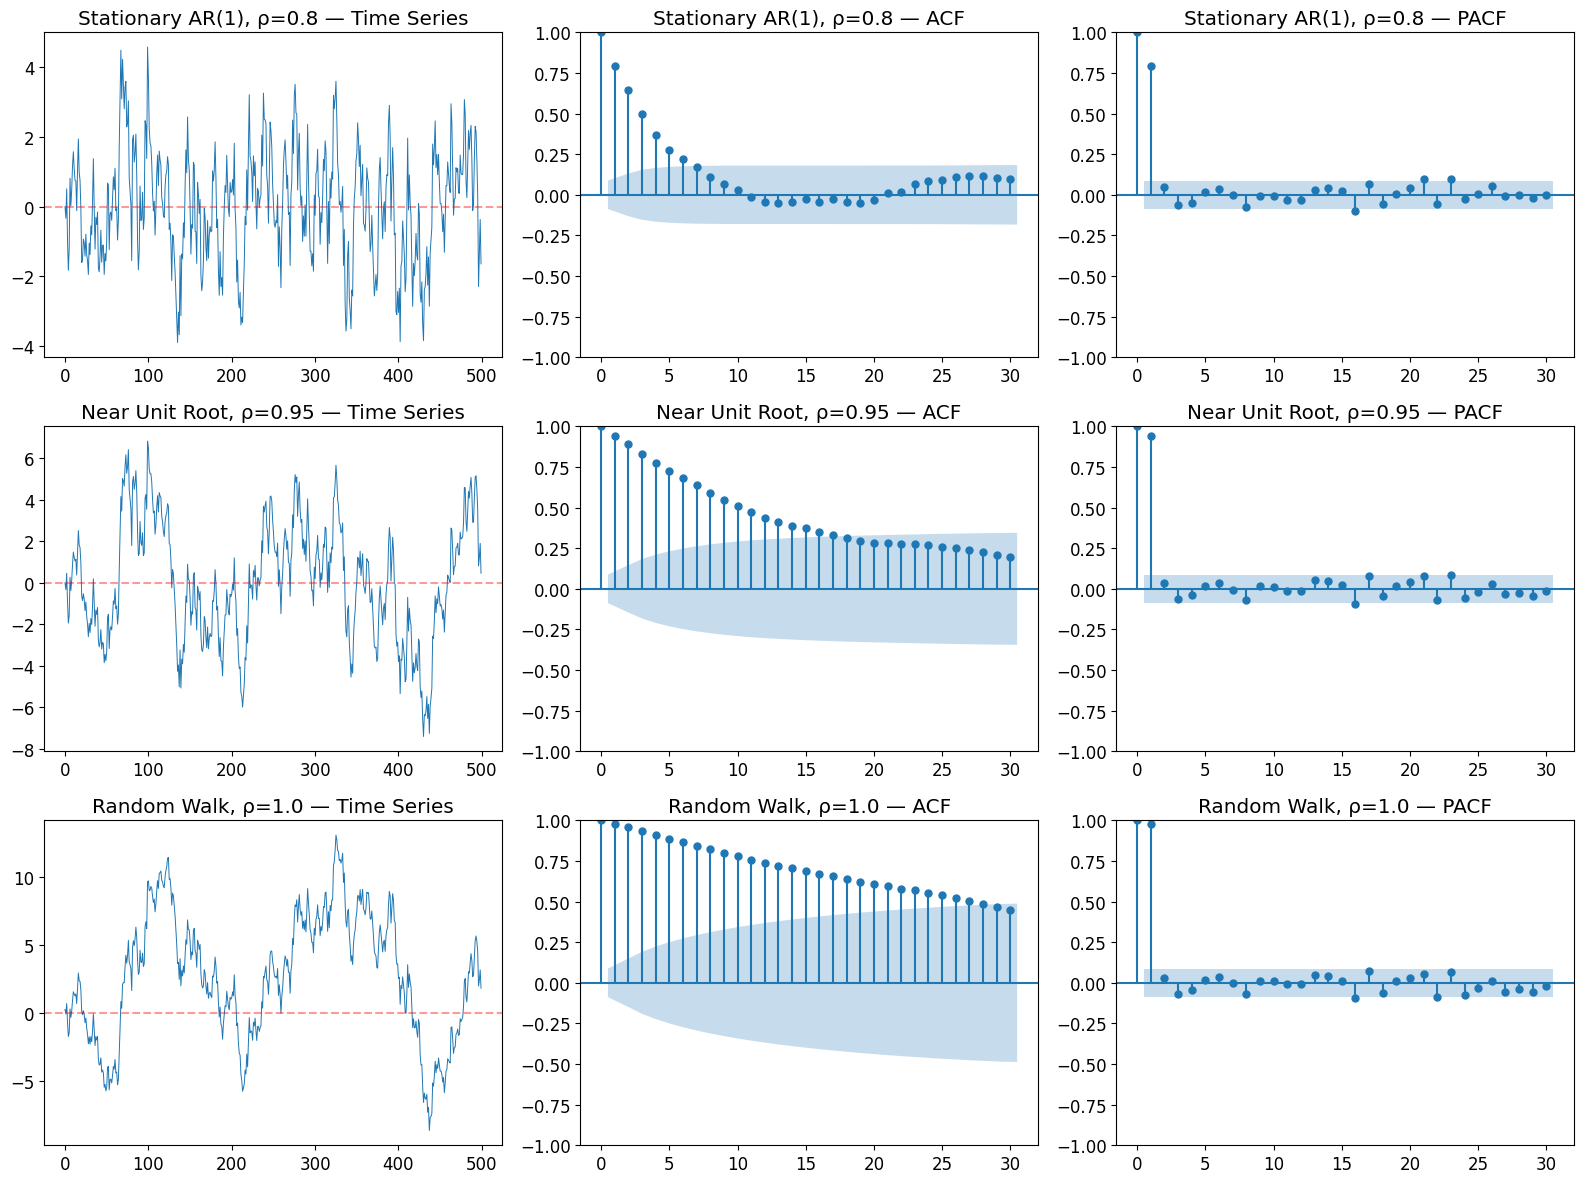

EXAM TIP: How to read these plots:
  Stationary (ρ=0.8): ACF decays geometrically, PACF cuts off at lag 1
  Near unit root (ρ=0.95): ACF decays VERY slowly — looks persistent
  Random walk (ρ=1): ACF barely decays at all (stays near 1), PACF ≈ 1 at lag 1

⚠ The ρ=0.95 and ρ=1.0 cases look very similar — this is the core problem!


In [4]:
# Compare ACF/PACF for stationary vs unit root
T = 500
eps = np.random.normal(0, 1, T)

# Stationary AR(1) with rho=0.8
y_stationary = np.zeros(T)
for t in range(1, T):
    y_stationary[t] = 0.8 * y_stationary[t-1] + eps[t]

# Random walk
y_rw = np.cumsum(eps)

# Near unit root (rho=0.95)
y_near = np.zeros(T)
for t in range(1, T):
    y_near[t] = 0.95 * y_near[t-1] + eps[t]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

data_list = [
    (y_stationary, 'Stationary AR(1), ρ=0.8'),
    (y_near, 'Near Unit Root, ρ=0.95'),
    (y_rw, 'Random Walk, ρ=1.0')
]

for i, (y, title) in enumerate(data_list):
    axes[i, 0].plot(y, linewidth=0.7)
    axes[i, 0].set_title(f'{title} — Time Series')
    axes[i, 0].axhline(0, color='red', linestyle='--', alpha=0.4)
    
    plot_acf(y, ax=axes[i, 1], lags=30, alpha=0.05)
    axes[i, 1].set_title(f'{title} — ACF')
    
    plot_pacf(y, ax=axes[i, 2], lags=30, alpha=0.05)
    axes[i, 2].set_title(f'{title} — PACF')

plt.tight_layout()
plt.show()

print('EXAM TIP: How to read these plots:')
print('  Stationary (ρ=0.8): ACF decays geometrically, PACF cuts off at lag 1')
print('  Near unit root (ρ=0.95): ACF decays VERY slowly — looks persistent')
print('  Random walk (ρ=1): ACF barely decays at all (stays near 1), PACF ≈ 1 at lag 1')
print()
print('⚠ The ρ=0.95 and ρ=1.0 cases look very similar — this is the core problem!')

---
## Part 4: Why It Matters — Deterministic vs. Stochastic Trend

This is the **most exam-relevant** section. Pesavento spent the most lecture time here.

### Three key differences:

| Aspect | Deterministic Trend | Stochastic Trend (Unit Root) |
|---|---|---|
| **Forecast** | Converges to trend line regardless of where you start | Depends on today's value $y_t$ |
| **Shock effect** | Temporary (dies out) | **Permanent** |
| **MSE** | Converges to finite value | Grows without bound |
| **Correct transformation** | Detrend ($y_t - ct$) | First difference ($\Delta y_t$) |
| **Wrong transformation** | Differencing introduces MA unit root | Detrending leaves variance exploding |

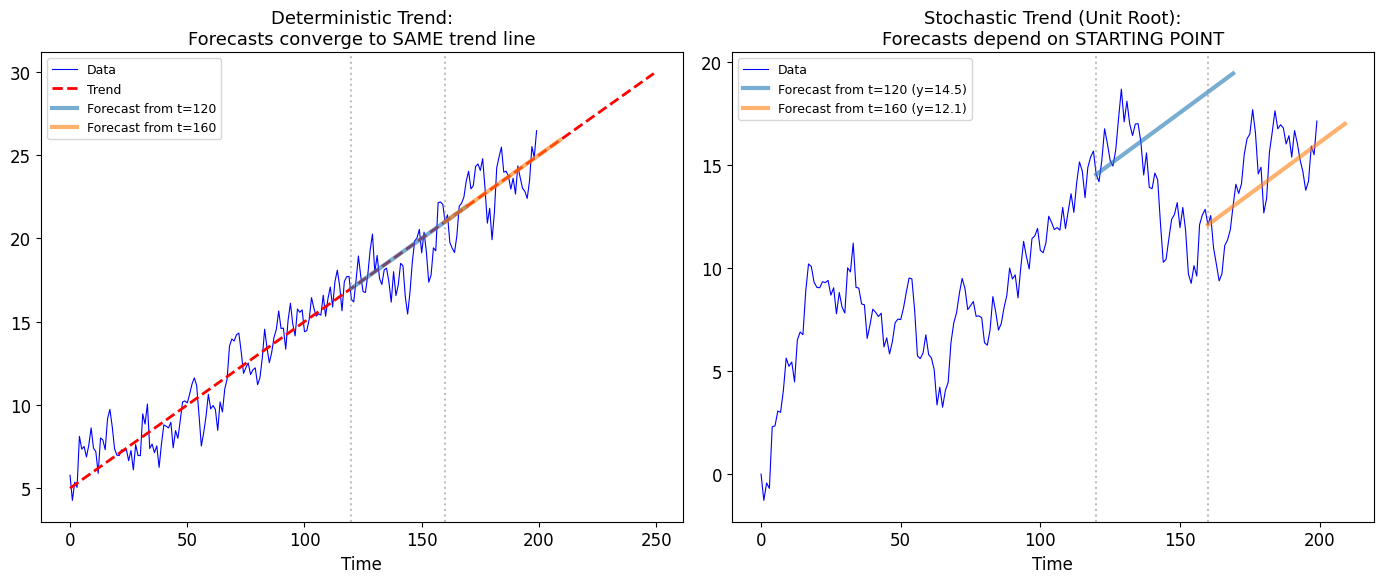

EXAM KEY POINT (Pesavento):
  Deterministic trend: "No matter where I start, I end up in the same place."
  Stochastic trend: "The starting point matters — every new data point changes the forecast."


In [5]:
# DEMONSTRATE: Forecasting from different starting points
T = 200
c = 0.1  # drift/trend slope
eps = np.random.normal(0, 1, T)

# Deterministic trend: y_t = alpha + c*t + AR(1) noise
y_det = np.zeros(T)
for t in range(T):
    ar_noise = 0.7 * (y_det[t-1] - 5 - c*(t-1)) + eps[t] if t > 0 else eps[t]
    y_det[t] = 5 + c * t + ar_noise

# Stochastic trend: random walk with drift
y_stoch = np.zeros(T)
for t in range(1, T):
    y_stoch[t] = c + y_stoch[t-1] + eps[t]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Deterministic trend forecasts
axes[0].plot(y_det, 'b-', linewidth=0.8, label='Data')
trend_line = 5 + c * np.arange(T + 50)
axes[0].plot(range(T + 50), trend_line, 'r--', linewidth=2, label='Trend')

# Forecasts from two different points
for start in [120, 160]:
    forecast_horizon = np.arange(start, start + 50)
    forecast = 5 + c * forecast_horizon
    axes[0].plot(forecast_horizon, forecast, linewidth=3, alpha=0.6,
                label=f'Forecast from t={start}')
    axes[0].axvline(start, color='gray', linestyle=':', alpha=0.5)

axes[0].set_title('Deterministic Trend:\nForecasts converge to SAME trend line', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Time')

# Stochastic trend forecasts
axes[1].plot(y_stoch, 'b-', linewidth=0.8, label='Data')

for start in [120, 160]:
    forecast_horizon = np.arange(start, start + 50)
    # Best forecast: y_t + c*s
    forecast = y_stoch[start] + c * (forecast_horizon - start)
    axes[1].plot(forecast_horizon, forecast, linewidth=3, alpha=0.6,
                label=f'Forecast from t={start} (y={y_stoch[start]:.1f})')
    axes[1].axvline(start, color='gray', linestyle=':', alpha=0.5)

axes[1].set_title('Stochastic Trend (Unit Root):\nForecasts depend on STARTING POINT', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

print('EXAM KEY POINT (Pesavento):')
print('  Deterministic trend: "No matter where I start, I end up in the same place."')
print('  Stochastic trend: "The starting point matters — every new data point changes the forecast."')

---
## Part 5: Dynamic Multipliers — Permanent vs. Temporary Shocks

The **dynamic multiplier** measures: if I shock $\varepsilon_t$ by 1 unit today, what is the effect on $y_{t+s}$?

- **Stationary:** $\frac{\partial y_{t+s}}{\partial \varepsilon_t} = \psi_s \to 0$ — shock dies out
- **Unit root:** $\frac{\partial y_{t+s}}{\partial \varepsilon_t} = 1 + \psi_1 + \cdots + \psi_s \to \Psi(1)$ — shock is **permanent**

Pesavento: *"Suppose I'm a policymaker and I want to surprise the economy by doing a policy shock. I need to know if the effect is going to be permanent or temporary."*

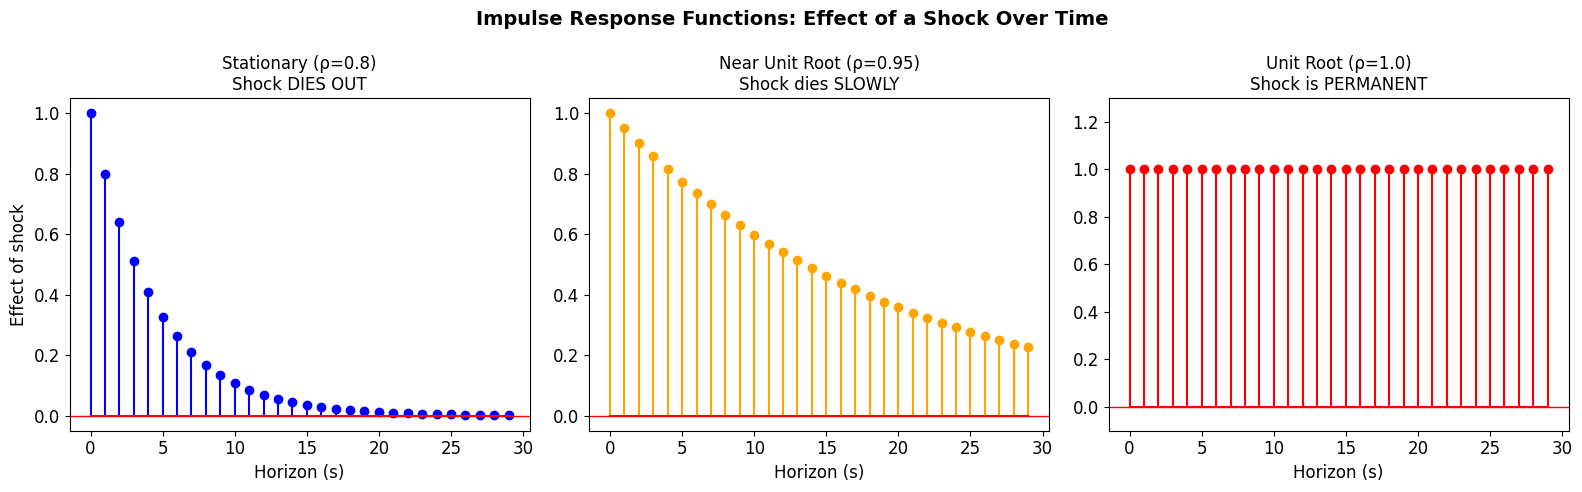

At horizon s=20:
  ρ=0.8:  effect = 0.0115 (essentially gone)
  ρ=0.95: effect = 0.3585 (still 36% remaining!)
  ρ=1.0:  effect = 1.0000 (never disappears)


In [6]:
# DEMONSTRATE: Impulse Response Functions
horizons = 30

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stationary AR(1), rho=0.8
irf_stat = [0.8**s for s in range(horizons)]
axes[0].stem(range(horizons), irf_stat, linefmt='b-', markerfmt='bo', basefmt='r-')
axes[0].set_title('Stationary (ρ=0.8)\nShock DIES OUT', fontsize=12)
axes[0].set_xlabel('Horizon (s)')
axes[0].set_ylabel('Effect of shock')
axes[0].axhline(0, color='red', linewidth=1)

# Near unit root, rho=0.95
irf_near = [0.95**s for s in range(horizons)]
axes[1].stem(range(horizons), irf_near, linefmt='orange', markerfmt='o', basefmt='r-')
axes[1].set_title('Near Unit Root (ρ=0.95)\nShock dies SLOWLY', fontsize=12)
axes[1].set_xlabel('Horizon (s)')
axes[1].axhline(0, color='red', linewidth=1)

# Unit root, rho=1
irf_ur = [1.0 for s in range(horizons)]
axes[2].stem(range(horizons), irf_ur, linefmt='r-', markerfmt='ro', basefmt='r-')
axes[2].set_title('Unit Root (ρ=1.0)\nShock is PERMANENT', fontsize=12)
axes[2].set_xlabel('Horizon (s)')
axes[2].axhline(0, color='red', linewidth=1)
axes[2].set_ylim(-0.1, 1.3)

plt.suptitle('Impulse Response Functions: Effect of a Shock Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('At horizon s=20:')
print(f'  ρ=0.8:  effect = {0.8**20:.4f} (essentially gone)')
print(f'  ρ=0.95: effect = {0.95**20:.4f} (still 36% remaining!)')
print(f'  ρ=1.0:  effect = 1.0000 (never disappears)')

---
## Part 6: The Wrong Transformation Problem

This is a subtle but critical exam point. There is **no single transformation** that works for both cases:

### If data is trend stationary:
- **Detrend** → $y_t - ct = \mu + \varepsilon_t$ → **stationary** (correct)
- **Difference** → $\Delta y_t = c + \varepsilon_t + \varepsilon_{t-1}$ → introduces **MA unit root** (wrong!), loses invertibility

### If data has a unit root:
- **Difference** → $\Delta y_t = c + \varepsilon_t$ → **stationary** (correct)
- **Detrend** → $y_t - ct = y_0 + \sum \varepsilon_j$ → still has variance $t\sigma^2$ (wrong!), not stationary

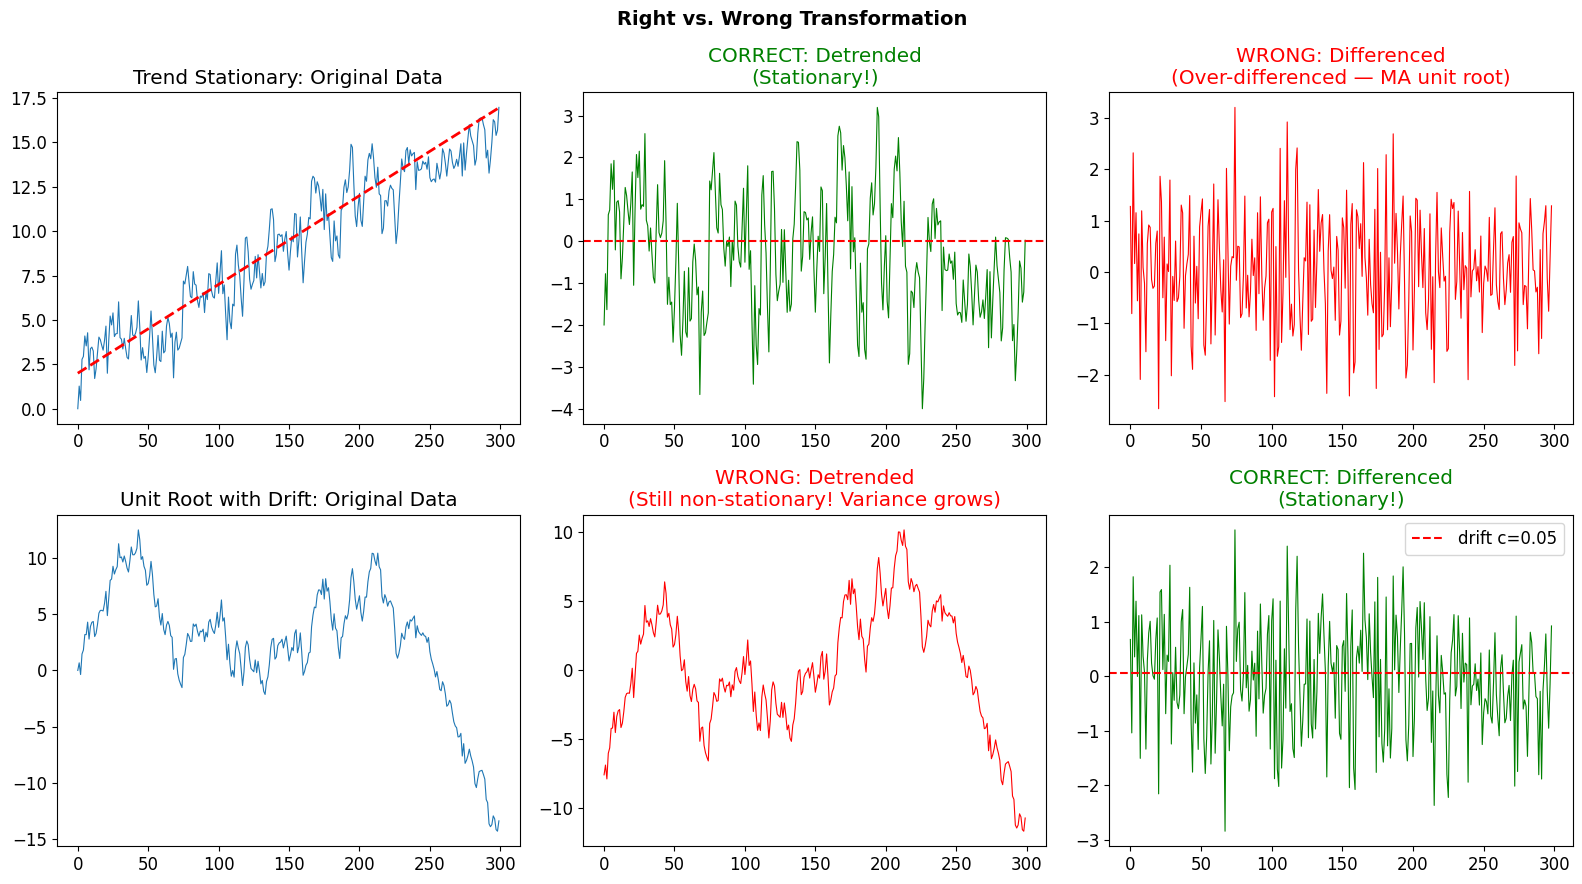

EXAM KEY POINT:
  Trend stationary → DETREND (do not difference)
  Unit root         → DIFFERENCE (do not just detrend)
  Using the wrong one creates NEW problems in the data.


In [7]:
# DEMONSTRATE: Right vs Wrong transformation
T = 300
c = 0.05
eps = np.random.normal(0, 1, T)

# Case 1: Trend stationary data
y_ts = 5 + c * np.arange(T) + np.cumsum(0.5 * eps - 0.5 * np.roll(eps, 1))  # stationary noise around trend
# Actually let's make a clean trend stationary
y_ts = np.zeros(T)
for t in range(1, T):
    y_ts[t] = 2 + 0.05 * t + 0.7 * (y_ts[t-1] - 2 - 0.05*(t-1)) + eps[t]

# Case 2: Unit root with drift
y_ur = np.zeros(T)
for t in range(1, T):
    y_ur[t] = 0.05 + y_ur[t-1] + eps[t]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Trend stationary
axes[0,0].plot(y_ts, linewidth=0.8)
axes[0,0].plot(2 + 0.05*np.arange(T), 'r--', linewidth=2)
axes[0,0].set_title('Trend Stationary: Original Data')

# Correct: detrend
detrended = y_ts - (2 + 0.05*np.arange(T))
axes[0,1].plot(detrended, linewidth=0.8, color='green')
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title('CORRECT: Detrended\n(Stationary!)', color='green')

# Wrong: difference
diff_ts = np.diff(y_ts)
axes[0,2].plot(diff_ts, linewidth=0.8, color='red')
axes[0,2].set_title('WRONG: Differenced\n(Over-differenced — MA unit root)', color='red')

# Row 2: Unit root
axes[1,0].plot(y_ur, linewidth=0.8)
axes[1,0].set_title('Unit Root with Drift: Original Data')

# Wrong: detrend 
trend = np.polyfit(np.arange(T), y_ur, 1)
detrended_ur = y_ur - (trend[0]*np.arange(T) + trend[1])
axes[1,1].plot(detrended_ur, linewidth=0.8, color='red')
axes[1,1].set_title('WRONG: Detrended\n(Still non-stationary! Variance grows)', color='red')

# Correct: difference
diff_ur = np.diff(y_ur)
axes[1,2].plot(diff_ur, linewidth=0.8, color='green')
axes[1,2].axhline(0.05, color='red', linestyle='--', label='drift c=0.05')
axes[1,2].set_title('CORRECT: Differenced\n(Stationary!)', color='green')
axes[1,2].legend()

plt.suptitle('Right vs. Wrong Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('EXAM KEY POINT:')
print('  Trend stationary → DETREND (do not difference)')
print('  Unit root         → DIFFERENCE (do not just detrend)')
print('  Using the wrong one creates NEW problems in the data.')

---
## Part 7: The Dickey-Fuller Test — Step by Step

### The Idea

Start with AR(1): $y_t = \rho \, y_{t-1} + \varepsilon_t$

Subtract $y_{t-1}$ from both sides:
$$\Delta y_t = \alpha \, y_{t-1} + \varepsilon_t \quad \text{where } \alpha = \rho - 1$$

### Hypotheses:
$$H_0: \alpha = 0 \quad (\rho = 1, \text{ unit root})$$
$$H_1: \alpha < 0 \quad (\rho < 1, \text{ stationary})$$

### The catch: Non-standard distribution
Under $H_0$, the t-statistic for $\hat{\alpha}$ does **NOT** follow a normal distribution. It follows the **Dickey-Fuller distribution**, which is shifted to the left. You must use DF critical values, not the standard -1.96.

### Critical Values (MEMORIZE THESE):

| Specification | 10% | 5% | 1% |
|---|---|---|---|
| Intercept only | -2.57 | -2.86 | -3.43 |
| Intercept + trend | -3.12 | -3.41 | -3.96 |

**Decision rule:** Reject $H_0$ (conclude NO unit root) if test statistic < critical value. **One-sided test, left tail.**

### The test is NON-PIVOTAL
Unlike standard tests, the critical values **change** depending on whether you include a constant, a trend, or neither. You must decide the specification **before** testing.

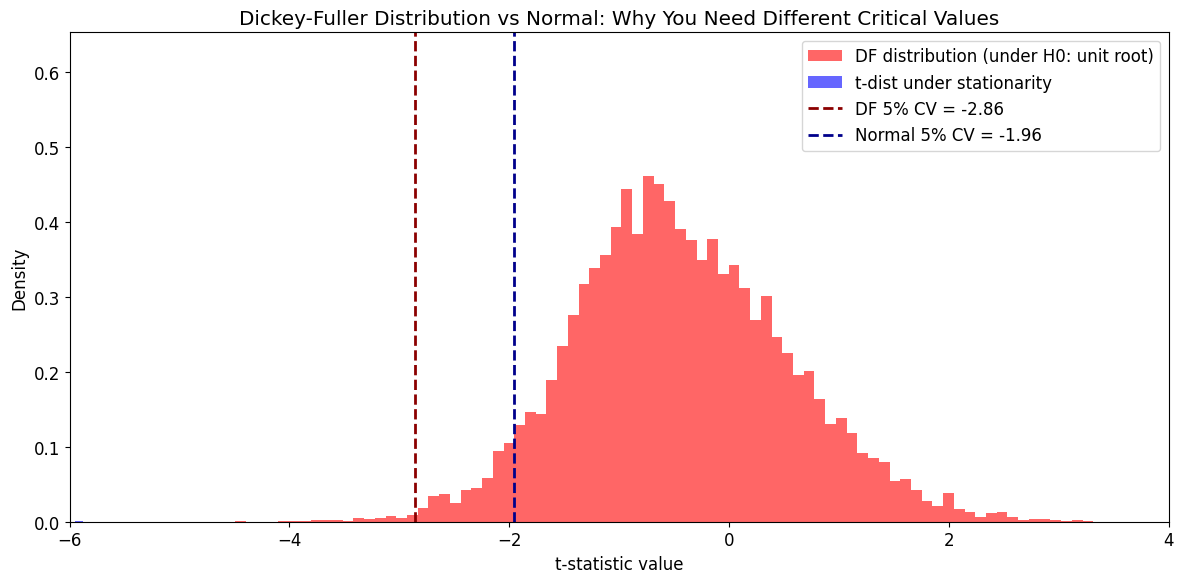

EXAM KEY POINT:
  If you used the normal 5% CV of -1.96, you would reject 5.0% of the time
  But the TRUE size should be 5%. Using DF CV of -2.86, rejection rate = 0.5%
  Using normal critical values → too many false rejections → conclude stationarity when there is a unit root!


In [8]:
# DEMONSTRATE: The DF distribution vs Normal
n_sims = 10000
T = 200
df_stats = []
normal_stats = []

for _ in range(n_sims):
    # Under H0: data is a random walk
    eps = np.random.normal(0, 1, T)
    y_rw = np.cumsum(eps)
    
    # Run the DF regression: Delta_y = alpha * y_{t-1}
    dy = np.diff(y_rw)
    y_lag = y_rw[:-1]
    
    # OLS: alpha_hat and t-stat
    alpha_hat = np.sum(dy * y_lag) / np.sum(y_lag**2)
    resid = dy - alpha_hat * y_lag
    se = np.sqrt(np.sum(resid**2) / (T-2) / np.sum(y_lag**2))
    t_stat = alpha_hat / se
    df_stats.append(t_stat)
    
    # For comparison: standard t-stat from stationary data
    y_stat = np.zeros(T)
    for t in range(1, T):
        y_stat[t] = 0.5 * y_stat[t-1] + eps[t]
    dy_s = np.diff(y_stat)
    y_lag_s = y_stat[:-1]
    alpha_hat_s = np.sum(dy_s * y_lag_s) / np.sum(y_lag_s**2)
    resid_s = dy_s - alpha_hat_s * y_lag_s
    se_s = np.sqrt(np.sum(resid_s**2) / (T-2) / np.sum(y_lag_s**2))
    normal_stats.append(alpha_hat_s / se_s)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_stats, bins=80, density=True, alpha=0.6, color='red', label='DF distribution (under H0: unit root)')
ax.hist(normal_stats, bins=80, density=True, alpha=0.6, color='blue', label='t-dist under stationarity')

# Mark critical values
ax.axvline(-2.86, color='darkred', linewidth=2, linestyle='--', label='DF 5% CV = -2.86')
ax.axvline(-1.96, color='darkblue', linewidth=2, linestyle='--', label='Normal 5% CV = -1.96')

ax.set_xlabel('t-statistic value')
ax.set_ylabel('Density')
ax.set_title('Dickey-Fuller Distribution vs Normal: Why You Need Different Critical Values')
ax.legend()
ax.set_xlim(-6, 4)
plt.tight_layout()
plt.show()

print('EXAM KEY POINT:')
print(f'  If you used the normal 5% CV of -1.96, you would reject {100*np.mean(np.array(df_stats) < -1.96):.1f}% of the time')
print(f'  But the TRUE size should be 5%. Using DF CV of -2.86, rejection rate = {100*np.mean(np.array(df_stats) < -2.86):.1f}%')
print('  Using normal critical values → too many false rejections → conclude stationarity when there is a unit root!')

---
## Part 8: ADF Test in Practice — Complete Walkthrough

### The Augmented Dickey-Fuller (ADF) adds lagged differences for richer dynamics:

$$\Delta Y_t = \mu + \alpha Y_{t-1} + \gamma_1 \Delta Y_{t-1} + \gamma_2 \Delta Y_{t-2} + \cdots + \gamma_{p-1} \Delta Y_{t-p+1} + u_t$$

### Pesavento's step-by-step procedure:
1. **Plot the data** — always look at it first
2. **Decide: intercept only or intercept + trend?** — based on visual inspection
3. **Choose lag length** — use AIC/BIC with a reasonable max (12 for monthly, 4 for quarterly)
4. **Run the test** and compare to DF critical values
5. **Interpret:** reject → no unit root; fail to reject → unit root

Data source: FRED
Sample: 1960-02 to 2025-12
Observations: 791


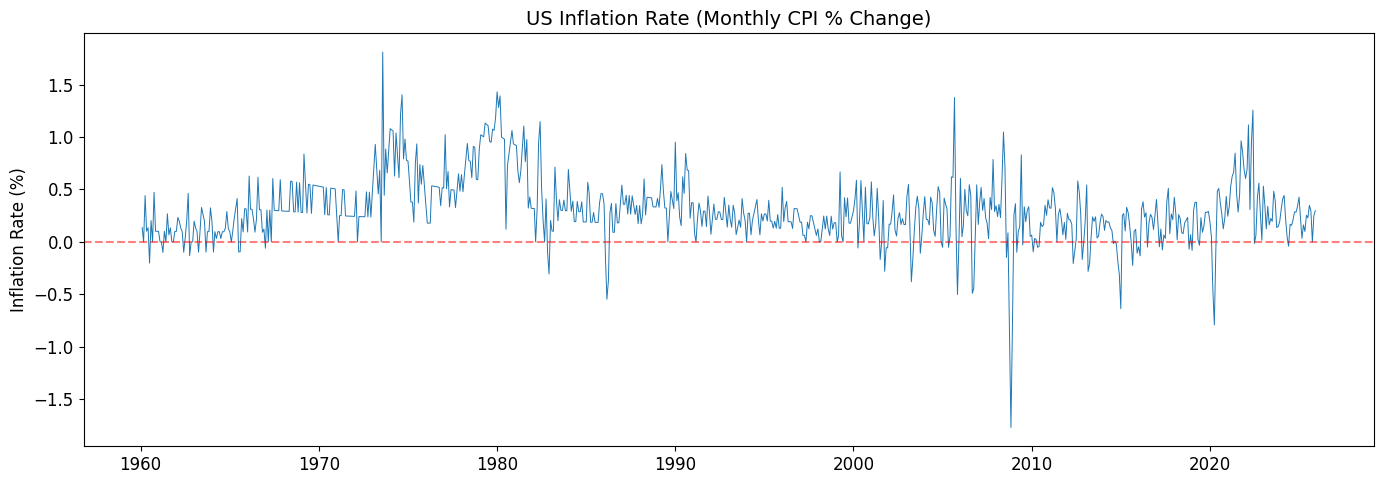


Step 2: Visual inspection → No obvious trend → use INTERCEPT ONLY


In [9]:
# WORKED EXAMPLE: Replicating the inflation example from class
import pandas_datareader.data as web
from datetime import datetime

# Fetch CPI data from FRED
try:
    cpi = web.DataReader('CPIAUCSL', 'fred', '1960-01-01', '2025-12-31')
    # Compute monthly inflation rate (percent change)
    inflation = cpi['CPIAUCSL'].pct_change().dropna() * 100
    inflation.name = 'Inflation Rate'
    data_source = 'FRED'
except:
    # Fallback: simulate inflation-like data
    np.random.seed(123)
    T = 780
    eps = np.random.normal(0, 0.3, T)
    inflation_arr = np.zeros(T)
    for t in range(1, T):
        inflation_arr[t] = 0.02 + 0.92 * inflation_arr[t-1] + eps[t]
    dates = pd.date_range('1960-01-01', periods=T, freq='MS')
    inflation = pd.Series(inflation_arr, index=dates, name='Inflation Rate')
    data_source = 'Simulated'

print(f'Data source: {data_source}')
print(f'Sample: {inflation.index[0].strftime("%Y-%m")} to {inflation.index[-1].strftime("%Y-%m")}')
print(f'Observations: {len(inflation)}')

# Step 1: Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(inflation, linewidth=0.7)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('US Inflation Rate (Monthly CPI % Change)', fontsize=14)
ax.set_ylabel('Inflation Rate (%)')
plt.tight_layout()
plt.show()

print('\nStep 2: Visual inspection → No obvious trend → use INTERCEPT ONLY')

In [10]:
# Step 3-5: Run ADF test
def run_adf_test(series, name, regression='c', maxlag=None):
    """Run ADF test and print results in exam-friendly format."""
    result = adfuller(series.dropna(), regression=regression, maxlag=maxlag, autolag='AIC')
    
    spec = 'Intercept only' if regression == 'c' else 'Intercept + Trend'
    print(f'=== ADF Test: {name} ===')
    print(f'Specification: {spec}')
    print(f'Lags selected (AIC): {result[2]}')
    print(f'---')
    print(f'ADF Statistic:  {result[0]:.4f}')
    print(f'p-value:        {result[1]:.6f}')
    print(f'---')
    print(f'Critical Values:')
    for key, val in result[4].items():
        marker = ' ← REJECT' if result[0] < val else ''
        print(f'  {key}: {val:.4f}{marker}')
    print(f'---')
    
    if result[1] < 0.05:
        print(f'CONCLUSION: REJECT H0 at 5% → Data does NOT have a unit root')
    elif result[1] < 0.10:
        print(f'CONCLUSION: REJECT H0 at 10% but NOT at 5% → Borderline case')
    else:
        print(f'CONCLUSION: FAIL TO REJECT H0 → Data likely has a unit root')
    print()
    return result

# Run with intercept only (as Pesavento did in class)
result_c = run_adf_test(inflation, 'US Inflation', regression='c', maxlag=12)

# Also run with trend for comparison
result_ct = run_adf_test(inflation, 'US Inflation', regression='ct', maxlag=12)

=== ADF Test: US Inflation ===
Specification: Intercept only
Lags selected (AIC): 11
---
ADF Statistic:  -3.7309
p-value:        0.003699
---
Critical Values:
  1%: -3.4388 ← REJECT
  5%: -2.8653 ← REJECT
  10%: -2.5687 ← REJECT
---
CONCLUSION: REJECT H0 at 5% → Data does NOT have a unit root

=== ADF Test: US Inflation ===
Specification: Intercept + Trend
Lags selected (AIC): 11
---
ADF Statistic:  -3.9970
p-value:        0.008880
---
Critical Values:
  1%: -3.9704 ← REJECT
  5%: -3.4161 ← REJECT
  10%: -3.1304 ← REJECT
---
CONCLUSION: REJECT H0 at 5% → Data does NOT have a unit root



In [11]:
# BONUS: Run KPSS stationarity test for comparison
# KPSS has H0: stationary, H1: unit root (opposite of ADF!)

def run_kpss_test(series, name, regression='c'):
    """Run KPSS test and print results."""
    result = kpss(series.dropna(), regression=regression, nlags='auto')
    spec = 'Level stationarity' if regression == 'c' else 'Trend stationarity'
    print(f'=== KPSS Test: {name} ===')
    print(f'H0: {spec}')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value:        {result[1]:.4f}')
    print(f'Lags used:      {result[2]}')
    print(f'Critical Values:')
    for key, val in result[3].items():
        print(f'  {key}: {val:.4f}')
    print(f'---')
    if result[1] < 0.05:
        print(f'CONCLUSION: REJECT H0 → Data is NOT stationary (has unit root)')
    else:
        print(f'CONCLUSION: FAIL TO REJECT H0 → Data appears stationary')
    print()

run_kpss_test(inflation, 'US Inflation', regression='c')

print('EXAM KEY POINT:')
print('  ADF: H0 = unit root    → reject means stationary')
print('  KPSS: H0 = stationary  → reject means unit root')
print('  If both agree: clear answer.')
print('  If they conflict: the borderline/ambiguous case Pesavento warned about.')

=== KPSS Test: US Inflation ===
H0: Level stationarity
KPSS Statistic: 0.9004
p-value:        0.0100
Lags used:      15
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
---
CONCLUSION: REJECT H0 → Data is NOT stationary (has unit root)

EXAM KEY POINT:
  ADF: H0 = unit root    → reject means stationary
  KPSS: H0 = stationary  → reject means unit root
  If both agree: clear answer.
  If they conflict: the borderline/ambiguous case Pesavento warned about.


---
## Part 9: Choosing Intercept vs. Intercept + Trend

This is a decision you make **before** running the test. Pesavento's rule:

| Data looks like... | Use... | Alternative hypothesis is... |
|---|---|---|
| Fluctuates around a level | Intercept only (`c`) | Y is stationary around a constant |
| Has an upward/downward drift | Intercept + trend (`ct`) | Y is stationary around a linear trend |

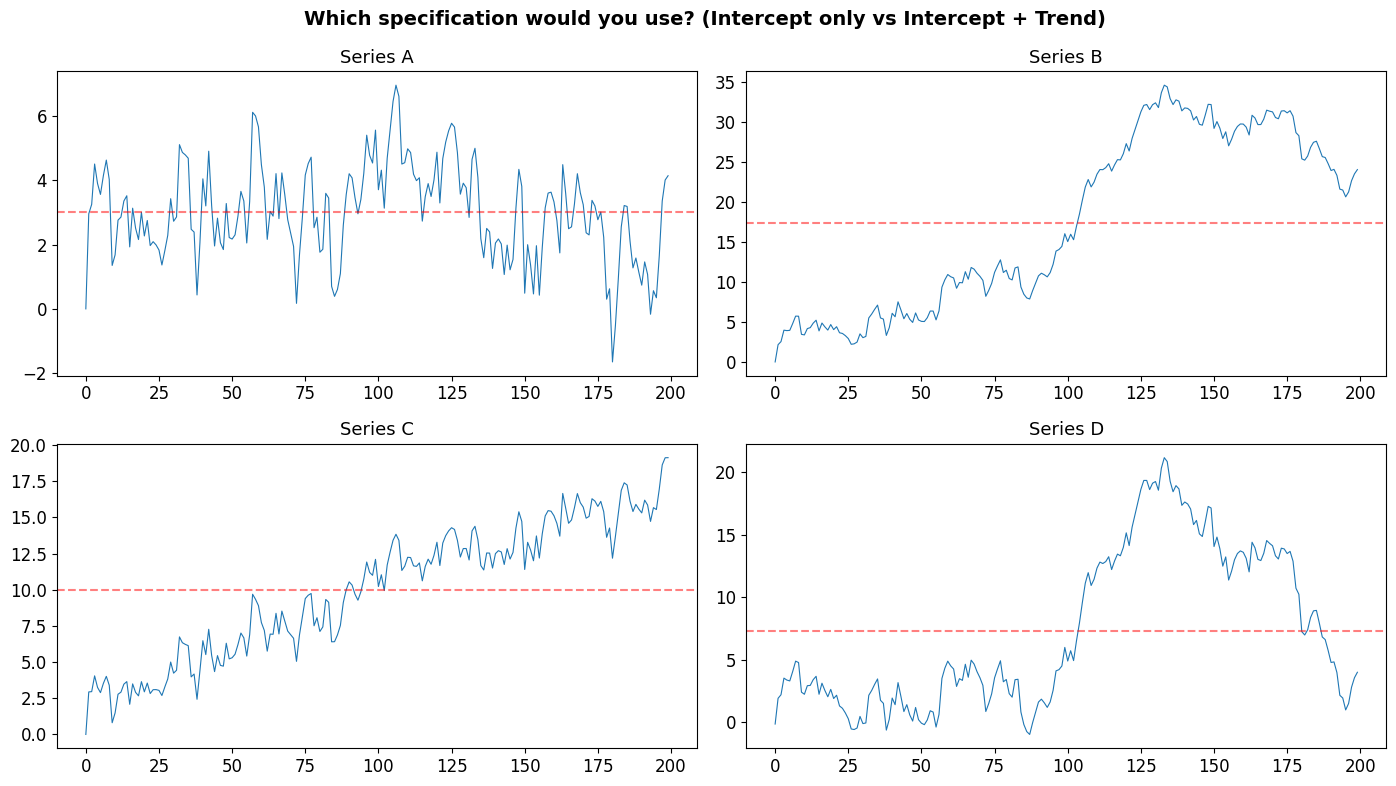

ANSWERS:
  Series A: Fluctuates around ~3 → INTERCEPT ONLY
  Series B: Clear upward movement → INTERCEPT + TREND
  Series C: Upward movement → INTERCEPT + TREND
  Series D: Long swings but no drift → INTERCEPT ONLY

  (B and C look similar visually — that is exactly the problem!
   B is actually a unit root with drift, C is trend stationary.)


In [12]:
# PRACTICE: Look at different series and decide the specification
np.random.seed(99)
T = 200
eps = np.random.normal(0, 1, T)

# Series A: Stationary around a constant
y_a = np.zeros(T)
for t in range(1, T):
    y_a[t] = 3 + 0.7 * (y_a[t-1] - 3) + eps[t]

# Series B: Has an upward trend
y_b = np.zeros(T)
for t in range(1, T):
    y_b[t] = 0.1 + y_b[t-1] + eps[t]  # RW with drift

# Series C: Trend stationary
y_c = np.zeros(T)
for t in range(1, T):
    y_c[t] = 2 + 0.08*t + 0.6*(y_c[t-1] - 2 - 0.08*(t-1)) + eps[t]

# Series D: Unit root, no drift
y_d = np.cumsum(eps)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
series = [(y_a, 'Series A'), (y_b, 'Series B'), (y_c, 'Series C'), (y_d, 'Series D')]

for ax, (y, name) in zip(axes.flatten(), series):
    ax.plot(y, linewidth=0.8)
    ax.set_title(name, fontsize=13)
    ax.axhline(np.mean(y), color='red', linestyle='--', alpha=0.5)

plt.suptitle('Which specification would you use? (Intercept only vs Intercept + Trend)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('ANSWERS:')
print('  Series A: Fluctuates around ~3 → INTERCEPT ONLY')
print('  Series B: Clear upward movement → INTERCEPT + TREND')
print('  Series C: Upward movement → INTERCEPT + TREND')  
print('  Series D: Long swings but no drift → INTERCEPT ONLY')
print()
print('  (B and C look similar visually — that is exactly the problem!')
print('   B is actually a unit root with drift, C is trend stationary.)')

In [13]:
# Run ADF on all four to see results
print('='*60)
print('ADF RESULTS FOR ALL FOUR SERIES')
print('='*60)

series_data = [
    (y_a, 'Series A (stationary around constant)', 'c'),
    (y_b, 'Series B (RW with drift)', 'ct'),
    (y_c, 'Series C (trend stationary)', 'ct'),
    (y_d, 'Series D (pure random walk)', 'c'),
]

for y, name, reg in series_data:
    result = adfuller(y, regression=reg, maxlag=12, autolag='AIC')
    verdict = 'REJECT H0 (stationary)' if result[1] < 0.05 else 'FAIL TO REJECT (unit root)'
    spec = 'c' if reg == 'c' else 'c+t'
    print(f'{name}')
    print(f'  Spec: {spec} | ADF stat: {result[0]:.3f} | p-value: {result[1]:.4f} | Lags: {result[2]} | → {verdict}')
    print()

ADF RESULTS FOR ALL FOUR SERIES
Series A (stationary around constant)
  Spec: c | ADF stat: -3.370 | p-value: 0.0120 | Lags: 5 | → REJECT H0 (stationary)

Series B (RW with drift)
  Spec: c+t | ADF stat: -0.669 | p-value: 0.9751 | Lags: 0 | → FAIL TO REJECT (unit root)

Series C (trend stationary)
  Spec: c+t | ADF stat: -3.890 | p-value: 0.0125 | Lags: 5 | → REJECT H0 (stationary)

Series D (pure random walk)
  Spec: c | ADF stat: -1.365 | p-value: 0.5988 | Lags: 0 | → FAIL TO REJECT (unit root)



---
## Part 10: Common Exam Traps & Practice Questions

### Trap 1: Confusing the null hypothesis direction
- **ADF: H0 = unit root.** Rejecting means the data IS stationary.
- **KPSS: H0 = stationary.** Rejecting means the data HAS a unit root.
- Students often get this backwards!

### Trap 2: Using normal critical values
- The DF distribution is shifted left. Normal CV of -1.96 would over-reject.
- Must use DF critical values (~-2.86 for 5% with intercept only).

### Trap 3: Forgetting the test is non-pivotal
- Including a trend changes the critical values. They become MORE negative (harder to reject).
- Intercept only 5%: -2.86 vs. Intercept+trend 5%: -3.41

### Trap 4: Thinking unit root = bad
- It's not bad, just different. If data has a unit root, work with first differences.
- Neither model is "better" — they have different implications.

### Trap 5: Structural breaks masquerading as unit roots
- Pesavento specifically discussed this: ignoring a break can make a stationary series look like a unit root.
- Always look at your data for obvious breaks before testing.

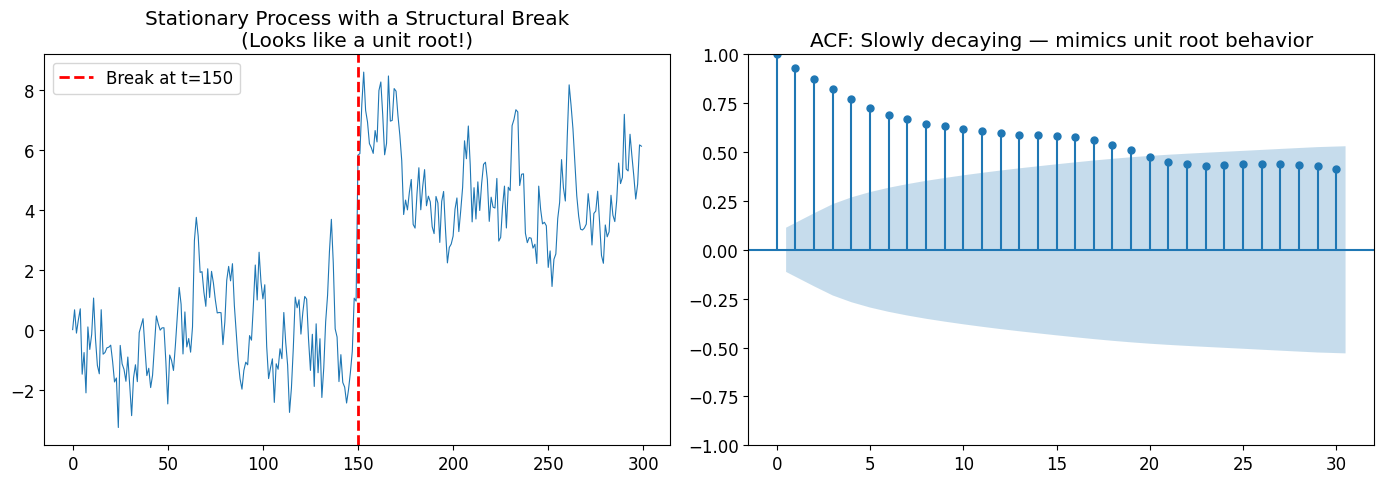

ADF test IGNORING the break:
  ADF stat: -3.141, p-value: 0.0236
  → REJECT: Correctly identifies stationarity (break not severe enough to fool the test this time)

Pesavento: "If there is an obvious break and you ignore it, you may conclude
there is a unit root when there isn't one. Always look at your data!"


In [14]:
# DEMONSTRATE TRAP 5: Break masquerading as unit root
np.random.seed(77)
T = 300
eps = np.random.normal(0, 1, T)

# Stationary process WITH a structural break at t=150
y_break = np.zeros(T)
for t in range(1, T):
    mean_level = 0 if t < 150 else 5  # mean shifts from 0 to 5
    y_break[t] = mean_level + 0.7 * (y_break[t-1] - (0 if t-1 < 150 else 5)) + eps[t]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_break, linewidth=0.8)
axes[0].axvline(150, color='red', linestyle='--', linewidth=2, label='Break at t=150')
axes[0].set_title('Stationary Process with a Structural Break\n(Looks like a unit root!)')
axes[0].legend()

# ACF
plot_acf(y_break, ax=axes[1], lags=30)
axes[1].set_title('ACF: Slowly decaying — mimics unit root behavior')

plt.tight_layout()
plt.show()

# Run ADF ignoring the break
result_break = adfuller(y_break, regression='c', autolag='AIC')
print(f'ADF test IGNORING the break:')
print(f'  ADF stat: {result_break[0]:.3f}, p-value: {result_break[1]:.4f}')
if result_break[1] > 0.05:
    print('  → FAIL TO REJECT: Falsely concludes unit root!')
else:
    print('  → REJECT: Correctly identifies stationarity (break not severe enough to fool the test this time)')

print()
print('Pesavento: "If there is an obvious break and you ignore it, you may conclude')
print('there is a unit root when there isn\'t one. Always look at your data!"')

---
## Part 11: Exam-Style Practice Problems

Work through these conceptual questions to test your understanding.

In [1]:
# Practice problems - run this cell to see questions, then the next cell for answers

questions = [
    {
        'q': 'Q1: You run an ADF test on GDP and get a test statistic of -2.10 with intercept + trend.\n'
             '    The 5% critical value is -3.41. What do you conclude?',
        'a': 'FAIL TO REJECT H0. -2.10 > -3.41 (not negative enough).\n'
             'Conclude: GDP likely has a unit root. Work with first differences (GDP growth rate).'
    },
    {
        'q': 'Q2: If y_t has a unit root, what is the best forecast of y_{t+10}?',
        'a': 'For a pure RW: y_t (today\'s value).\n'
             'For a RW with drift: y_t + 10c (today + 10 times the drift).\n'
             'The forecast DEPENDS on y_t — the starting point matters.'
    },
    {
        'q': 'Q3: You difference a trend-stationary series. What goes wrong?',
        'a': 'You introduce a unit root in the MA part.\n'
             'If y_t = alpha + ct + rho*y_{t-1} + eps_t (trend stationary),\n'
             'then Delta_y_t = c + eps_t + eps_{t-1} (has an MA unit root).\n'
             'This is over-differencing — you lose invertibility.'
    },
    {
        'q': 'Q4: ADF test rejects at 10% but not at 5%. What does Pesavento recommend?',
        'a': '"Stop and spend some time thinking. Make a decision and go with it,\n'
             'but ready to justify your decision." Run additional tests (KPSS, DF-GLS).\n'
             'Consider economic reasoning. Check for structural breaks.\n'
             'This is a borderline case — there is no automatic answer.'
    },
    {
        'q': 'Q5: Why can\'t you use -1.96 as the critical value for a unit root test?',
        'a': 'Under the null of a unit root, the t-statistic does NOT follow a normal distribution.\n'
             'It follows the Dickey-Fuller distribution, which is shifted to the LEFT.\n'
             'Using -1.96 would cause too many false rejections (over-reject the null).\n'
             'The correct 5% CV is about -2.86 (intercept only) or -3.41 (intercept+trend).'
    },
    {
        'q': 'Q6: A policymaker shocks the economy. Under what model does the effect persist forever?',
        'a': 'Under a UNIT ROOT model, the effect of a shock is permanent.\n'
             'The dynamic multiplier converges to Psi(1) ≠ 0 as s → infinity.\n'
             'Under a STATIONARY model, the effect dies out (multiplier → 0).\n'
             'This is why knowing the data-generating process matters for policy analysis.'
    },
    {
        'q': 'Q7: What does I(1) mean? What about I(0)?',
        'a': 'I(1): Integrated of order 1 — need to difference ONCE to get stationarity.\n'
             '      Example: random walk. Delta_y_t is stationary.\n'
             'I(0): Integrated of order 0 — already stationary, no differencing needed.\n'
             '      Example: any stationary ARMA process.'
    },
    {
        'q': 'Q8: The ACF of your data decays extremely slowly (values near 0.95 at lag 20).\n'
             '    The PACF has one large spike at lag 1 (~0.98) and drops to near zero.\n'
             '    What do you suspect?',
        'a': 'This is the classic signature of a unit root (or near-unit-root) process.\n'
             'ACF that barely decays = very persistent process.\n'
             'PACF with one spike at lag 1 near 1 = AR(1) with rho ≈ 1.\n'
             'You should run a formal ADF test to confirm.'
    },
]

print('='*70)
print('EXAM PRACTICE QUESTIONS')
print('='*70)
for i, item in enumerate(questions):
    print(f'\n{item["q"]}')
    print()

EXAM PRACTICE QUESTIONS

Q1: You run an ADF test on GDP and get a test statistic of -2.10 with intercept + trend.
    The 5% critical value is -3.41. What do you conclude?


Q2: If y_t has a unit root, what is the best forecast of y_{t+10}?


Q3: You difference a trend-stationary series. What goes wrong?


Q4: ADF test rejects at 10% but not at 5%. What does Pesavento recommend?


Q5: Why can't you use -1.96 as the critical value for a unit root test?


Q6: A policymaker shocks the economy. Under what model does the effect persist forever?


Q7: What does I(1) mean? What about I(0)?


Q8: The ACF of your data decays extremely slowly (values near 0.95 at lag 20).
    The PACF has one large spike at lag 1 (~0.98) and drops to near zero.
    What do you suspect?



In [16]:
# Run this cell to see the answers
print('='*70)
print('ANSWERS')
print('='*70)
for i, item in enumerate(questions):
    print(f'\n{item["q"]}')
    print(f'\n  ANSWER: {item["a"]}')
    print('-'*70)

ANSWERS

Q1: You run an ADF test on GDP and get a test statistic of -2.10 with intercept + trend.
    The 5% critical value is -3.41. What do you conclude?

  ANSWER: FAIL TO REJECT H0. -2.10 > -3.41 (not negative enough).
Conclude: GDP likely has a unit root. Work with first differences (GDP growth rate).
----------------------------------------------------------------------

Q2: If y_t has a unit root, what is the best forecast of y_{t+10}?

  ANSWER: For a pure RW: y_t (today's value).
For a RW with drift: y_t + 10c (today + 10 times the drift).
The forecast DEPENDS on y_t — the starting point matters.
----------------------------------------------------------------------

Q3: You difference a trend-stationary series. What goes wrong?

  ANSWER: You introduce a unit root in the MA part.
If y_t = alpha + ct + rho*y_{t-1} + eps_t (trend stationary),
then Delta_y_t = c + eps_t + eps_{t-1} (has an MA unit root).
This is over-differencing — you lose invertibility.
-----------------------

---
## Part 12: Pesavento's Decision Framework — Quick Reference

```
1. PLOT your data
   │
   ├─ Obvious trend? ──→ Include trend in ADF test (regression='ct')
   │
   └─ No trend? ──────→ Intercept only (regression='c')
         │
2. RUN ADF test (choose lags via AIC, set reasonable max)
   │
   ├─ Clear rejection (all levels)? ──→ NO unit root. Model y_t in levels.
   │
   ├─ Clear fail-to-reject? ──────────→ UNIT ROOT. Take first difference.
   │                                     Model Δy_t with ARMA.
   │
   └─ Borderline? ────────────────────→ THINK. Run more tests (KPSS, DF-GLS).
                                         Consider breaks, economic reasoning.
                                         Make a defensible decision.

3. If unit root confirmed:
   - Use Δy_t for all analysis and forecasting
   - In Python: ARIMA(p, 1, q) or manually difference first
   - Shocks have PERMANENT effects
   - MSE grows with forecast horizon

4. If stationary:
   - Model y_t directly (detrend if needed)
   - Use ARMA(p, q) on detrended data
   - Shocks die out
   - MSE converges to finite value
```

### Pesavento's final wisdom:
> *"This is not an easy question. Make a good case for what you want to do and move on."*

> *"When in doubt, you are always better off NOT imposing a restriction that may be wrong."*

> *"More consensus lately on using robust methods — leave things in levels, especially in VARs."*

---
## Part 13: Formula Cheat Sheet

### Models
| Name | Equation |
|---|---|
| Random Walk | $y_t = y_{t-1} + \varepsilon_t$ |
| RW with Drift | $y_t = c + y_{t-1} + \varepsilon_t$ |
| Back-substitution | $y_t = y_0 + \sum_{j=1}^{t} \varepsilon_j$ |
| Trend Stationary | $y_t = \alpha + ct + \Psi(L)\varepsilon_t$ |

### Properties of Random Walk
| Property | Formula |
|---|---|
| Variance | $\text{Var}(y_t) = t\sigma^2$ |
| Autocovariance | $\gamma_k = (t-k)\sigma^2$ |
| Autocorrelation | $\rho_k = \sqrt{(t-k)/t} \to 1$ |

### Testing
| Item | Formula/Value |
|---|---|
| DF Reparameterization | $\Delta y_t = \alpha y_{t-1} + \varepsilon_t$, $\alpha = \rho - 1$ |
| Null | $H_0: \alpha = 0$ (unit root) |
| Alternative | $H_1: \alpha < 0$ (stationary) |
| Test stat | $t = \hat{\alpha}/SE(\hat{\alpha})$ |
| 5% CV (intercept) | $-2.86$ |
| 5% CV (intercept+trend) | $-3.41$ |
| Decision | Reject if $t < \text{CV}$ |

### Forecasting
| Type | Long-run forecast |
|---|---|
| Deterministic trend | $y^f_{t,s} \to \alpha + c(t+s)$ (independent of $y_t$) |
| Stochastic trend | $y^f_{t,s} \to sc + y_t$ (depends on $y_t$) |

### Dynamic Multipliers
| Type | Long-run effect of shock |
|---|---|
| Stationary | $\partial y_{t+s}/\partial\varepsilon_t \to 0$ (temporary) |
| Unit Root | $\partial y_{t+s}/\partial\varepsilon_t \to \Psi(1)$ (permanent) |